
MODELO LINEAL (RIDGE)
Scores: [-1.08050788  0.8096894   0.34055362  0.80504412  0.82284721]
Promedio: 0.3395252943155331

Mejores parámetros (Random Forest):
{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Mejor R2 CV (Random Forest):
0.8845325877961526

RESULTADOS TEST (Random Forest)
R2: 0.8871254198574352
RMSE: 0.2575610070304639
MAE: 0.18248596101098732

Cross Validation Scores (RF):
[0.91192076 0.86679613 0.87840488 0.86775121 0.86819867]
Promedio CV: 0.8786143287149855


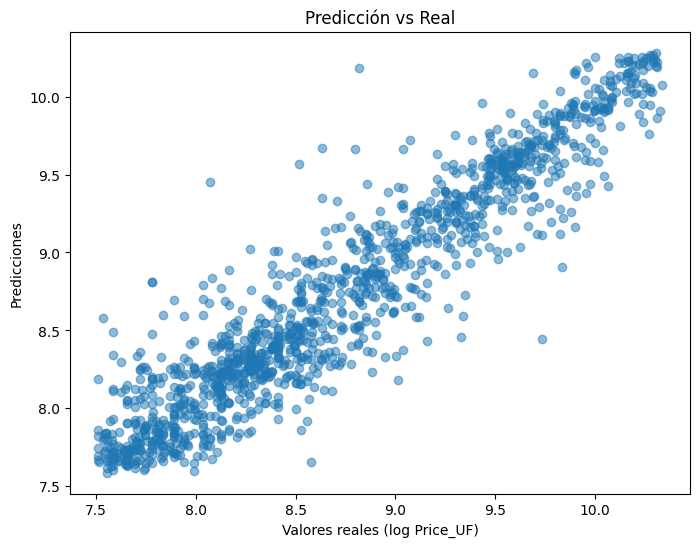

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


data = pd.read_csv("2023-03-08 Precios Casas RM.csv")


# LIMPIEZA

data = data.drop(columns=[
    "Price_CLP",
    "Price_USD",
    "Ubicacion",
    "id",
    "Realtor"
])


num_cols = data.select_dtypes(include=np.number).columns

imputer = KNNImputer(n_neighbors=5)
data_num = pd.DataFrame(imputer.fit_transform(data[num_cols]), columns=num_cols)


data_num["Comuna"] = data["Comuna"].values


lower = data_num["Price_UF"].quantile(0.05)
upper = data_num["Price_UF"].quantile(0.95)

data_clean = data_num[
    (data_num["Price_UF"] >= lower) &
    (data_num["Price_UF"] <= upper)
].copy()


data_clean = data_clean[
    (data_clean["Built Area"] < 1000) &
    (data_clean["Total Area"] < 2000)
]


data_clean.loc[:, "Area_ratio"] = data_clean["Built Area"] / data_clean["Total Area"]
data_clean.loc[:, "Rooms"] = data_clean["Dorms"] + data_clean["Baths"]

data_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
data_clean.dropna(inplace=True)


data_clean = pd.get_dummies(data_clean, columns=["Comuna"], drop_first=True)

#  DEFINIR X E y

y = np.log1p(data_clean["Price_UF"])
X = data_clean.drop(columns=["Price_UF"])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 🔵 9. MODELO LINEAL

pipeline_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10))
])

scores_linear = cross_val_score(
    pipeline_linear,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("\nMODELO LINEAL (RIDGE)")
print("Scores:", scores_linear)
print("Promedio:", scores_linear.mean())


# MODELO RANDOM FOREST 

pipeline = Pipeline([
    ("model", RandomForestRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5]
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\nMejores parámetros (Random Forest):")
print(grid.best_params_)

print("\nMejor R2 CV (Random Forest):")
print(grid.best_score_)



best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("\nRESULTADOS TEST (Random Forest)")
print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))


#  CROSS VALIDATION 

scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("\nCross Validation Scores (RF):")
print(scores)
print("Promedio CV:", scores.mean())



plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Valores reales (log Price_UF)")
plt.ylabel("Predicciones")
plt.title("Predicción vs Real")
plt.show()

El modelo Ridge obtuvo un R² promedio de 0.34 en validación cruzada, con alta variabilidad entre folds (incluso un valor negativo de -1.08).
Esto indica que el modelo es inestable y no logra capturar adecuadamente la relación entre las variables.
El modelo Random Forest logró un R² de 0.88 en validación cruzada y 0.887 en test, mostrando a lto poder explicativo resultados consistentes entre folds y buen ajuste El modelo lineal no es suficiente para este problema, mientras que Random Forest permite obtener un desempeño superior, alcanzando el objetivo propuesto de R² > 0.8.